In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/snehaanbhawal/resume-dataset/Resume/Resume.csv
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/22506245.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/13998435.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/67582956.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/34349255.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/26790545.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/12674307.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/11807040.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/44145704.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/27497542.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/11155153.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/17555081.pdf
/kaggl

# Install & Import Libraries

In [2]:
# Install any missing libraries
!pip install nltk scikit-learn pandas matplotlib seaborn wordcloud --quiet

import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_score

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# Load & Explore the Data

In [3]:
df = pd.read_csv('/kaggle/input/datasets/snehaanbhawal/resume-dataset/Resume/Resume.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst row preview:")
df.head(2)

Shape: (2484, 4)

Columns: ['ID', 'Resume_str', 'Resume_html', 'Category']

First row preview:


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR


📊 Category Counts:

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


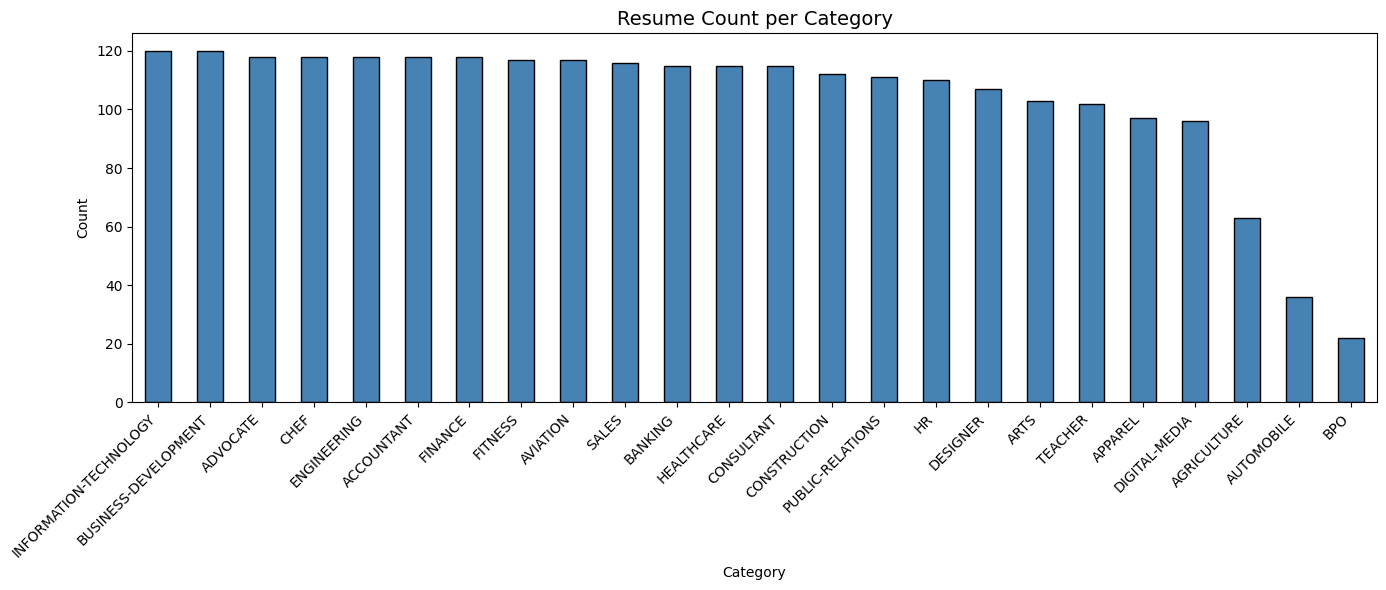

In [4]:
# Check category distribution
print("📊 Category Counts:\n")
print(df['Category'].value_counts())

# Plot
plt.figure(figsize=(14, 6))
df['Category'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Resume Count per Category', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Text Preprocessing

In [5]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_resume(text):
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Lowercase
    text = text.lower()
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords and apply stemming
    tokens = [stemmer.stem(w) for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

print("🔄 Cleaning resume text...")
df['Cleaned_Resume'] = df['Resume_str'].apply(clean_resume)
print("✅ Done! Sample cleaned text:")
print(df['Cleaned_Resume'][0][:300])

🔄 Cleaning resume text...
✅ Done! Sample cleaned text:
administratormarket associ administr summari dedic custom servic manag year experi hospit custom servic manag respect builder leader customerfocus team strive instil share enthusiast commit custom servic highlight focus custom satisfact team manag market savvi conflict resolut techniqu train develop


# TF-IDF Feature Extraction

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=1500,
    min_df=3,
    max_df=0.85
)

X = tfidf.fit_transform(df['Cleaned_Resume'])
print(f"✅ TF-IDF Matrix Shape: {X.shape}")

✅ TF-IDF Matrix Shape: (2484, 1500)


# Elbow Method

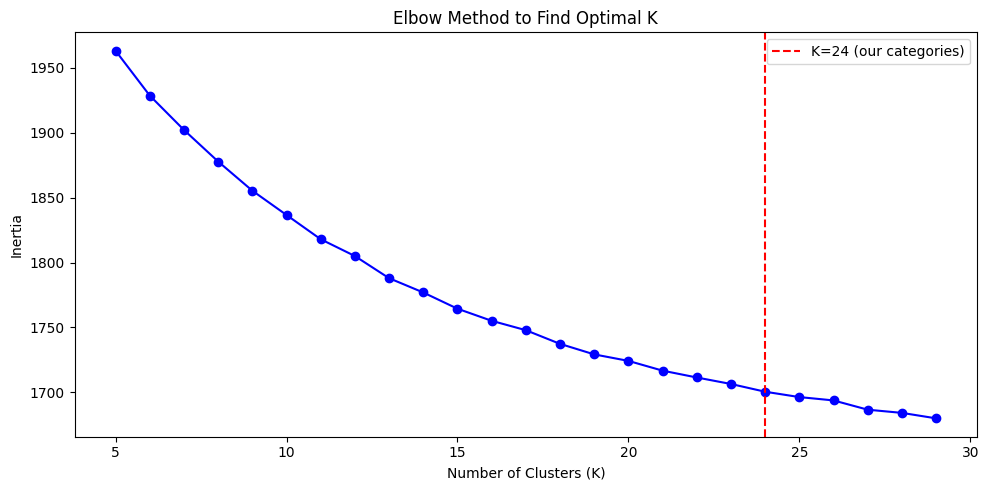

In [7]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_range = range(5, 30)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia, 'bo-', markersize=6)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method to Find Optimal K')
plt.axvline(x=24, color='red', linestyle='--', label='K=24 (our categories)')
plt.legend()
plt.tight_layout()
plt.show()

# Train K-Means

In [8]:
from sklearn.metrics import silhouette_score

K = 24

print(f"Training KMeans with K={K}...")
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10, max_iter=300)
df['Cluster'] = kmeans.fit_predict(X)

score = silhouette_score(X, df['Cluster'], sample_size=500)
print(f"✅ Silhouette Score: {score:.4f}  (closer to 1.0 is better)")

Training KMeans with K=24...
✅ Silhouette Score: 0.0537  (closer to 1.0 is better)


# PCA Visualization

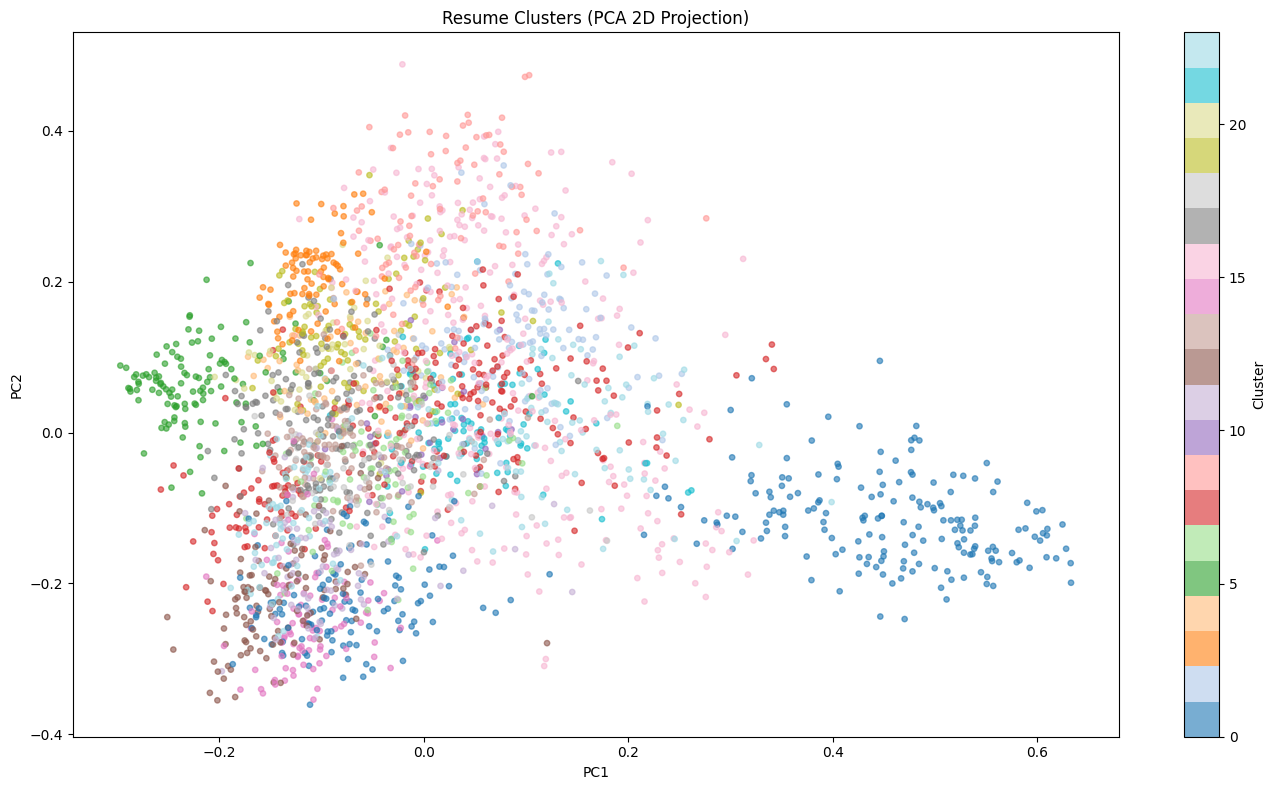

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X.toarray())

plt.figure(figsize=(14, 8))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1],
                      c=df['Cluster'], cmap='tab20',
                      alpha=0.6, s=15)
plt.colorbar(scatter, label='Cluster')
plt.title('Resume Clusters (PCA 2D Projection)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

# Top Keywords per Cluster

In [10]:
feature_names = tfidf.get_feature_names_out()
cluster_centers = kmeans.cluster_centers_

print("Top 10 keywords per cluster:\n")
for i in range(K):
    top_indices = cluster_centers[i].argsort()[-10:][::-1]
    top_words = [feature_names[idx] for idx in top_indices]
    print(f"Cluster {i:2d}: {', '.join(top_words)}")

Top 10 keywords per cluster:

Cluster  0: account, financi, tax, report, reconcili, prepar, statement, ledger, bank, monthli
Cluster  1: system, project, develop, applic, test, data, sql, busi, technolog, server
Cluster  2: sale, busi, market, custom, develop, account, client, new, product, territori
Cluster  3: food, chef, kitchen, cook, menu, culinari, restaur, cater, sanit, prepar
Cluster  4: famili, health, child, client, servic, children, program, case, commun, advoc
Cluster  5: student, teacher, classroom, lesson, children, teach, instruct, learn, parent, school
Cluster  6: market, digit, media, campaign, develop, sale, brand, strategi, product, content
Cluster  7: design, graphic, interior, product, art, illustr, adob, develop, color, project
Cluster  8: offic, custom, assist, administr, file, servic, claim, account, process, report
Cluster  9: custom, store, sale, merchandis, cash, servic, clean, product, inventori, stock
Cluster 10: recruit, candid, hire, employe, job, intervi

# Resume Scoring Function

In [11]:
def score_resume(resume_text, target_category, top_n_keywords=20):
    category_resumes = df[df['Category'] == target_category]['Cleaned_Resume']
    
    cat_tfidf = TfidfVectorizer(max_features=500)
    cat_matrix = cat_tfidf.fit_transform(category_resumes)
    
    mean_scores = cat_matrix.mean(axis=0).A1
    top_idx = mean_scores.argsort()[-top_n_keywords:][::-1]
    category_keywords = set([cat_tfidf.get_feature_names_out()[i] for i in top_idx])
    
    cleaned = clean_resume(resume_text)
    resume_words = set(cleaned.split())
    
    matches = len(resume_words.intersection(category_keywords))
    score = min(10, round((matches / top_n_keywords) * 10, 2))
    
    return score, list(resume_words.intersection(category_keywords))

# Test it
sample_resume = df[df['Category'] == 'INFORMATION-TECHNOLOGY']['Resume_str'].iloc[0]
score, matched = score_resume(sample_resume, 'INFORMATION-TECHNOLOGY')

print(f"Resume Score for IT Category: {score}/10")
print(f"Matched Keywords: {matched}")

Resume Score for IT Category: 9.5/10
Matched Keywords: ['implement', 'busi', 'softwar', 'develop', 'support', 'network', 'manag', 'compani', 'project', 'secur', 'citi', 'applic', 'state', 'server', 'data', 'technolog', 'name', 'inform', 'system']


# Score All Resumes

Scoring all resumes against their own category...


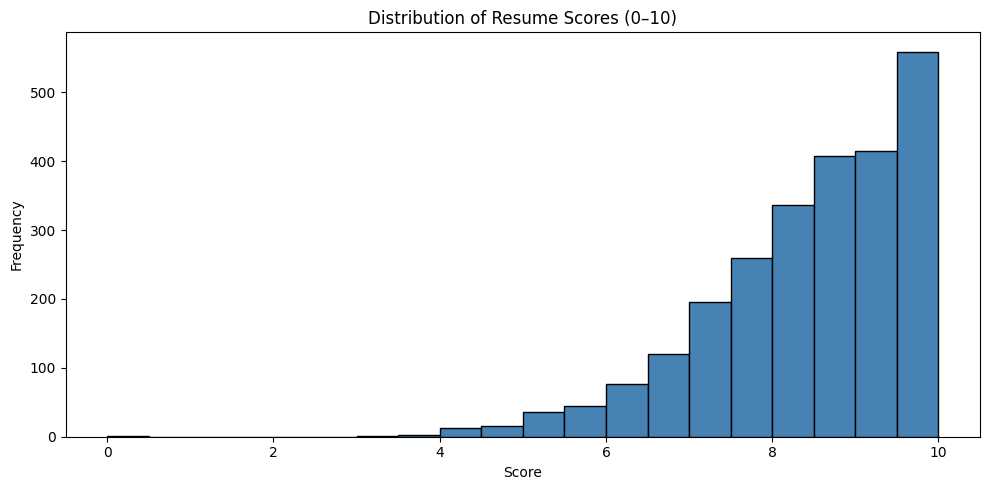


Score Stats:
count    2484.000000
mean        8.221820
std         1.265624
min         0.000000
25%         7.500000
50%         8.500000
75%         9.000000
max        10.000000
Name: Score, dtype: float64


In [12]:
print("Scoring all resumes against their own category...")

df['Score'] = df.apply(
    lambda row: score_resume(row['Resume_str'], row['Category'])[0],
    axis=1
)

plt.figure(figsize=(10, 5))
plt.hist(df['Score'], bins=20, color='steelblue', edgecolor='black')
plt.title('Distribution of Resume Scores (0–10)')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"\nScore Stats:\n{df['Score'].describe()}")

# Top & Bottom Resumes

In [13]:
print("Top 10 Highest Scoring Resumes:\n")
print(df[['Category', 'Score']].sort_values('Score', ascending=False).head(10).to_string(index=False))

print("\nBottom 10 Lowest Scoring Resumes:\n")
print(df[['Category', 'Score']].sort_values('Score').head(10).to_string(index=False))

Top 10 Highest Scoring Resumes:

Category  Score
      HR   10.0
      HR   10.0
     BPO   10.0
    CHEF   10.0
      HR   10.0
      HR   10.0
      HR   10.0
      HR   10.0
      HR   10.0
      HR   10.0

Bottom 10 Lowest Scoring Resumes:

              Category  Score
  BUSINESS-DEVELOPMENT    0.0
          CONSTRUCTION    3.0
          CONSTRUCTION    3.5
INFORMATION-TECHNOLOGY    3.5
               BANKING    4.0
      PUBLIC-RELATIONS    4.0
            ACCOUNTANT    4.0
              AVIATION    4.0
         DIGITAL-MEDIA    4.0
              DESIGNER    4.0


# WordCloud

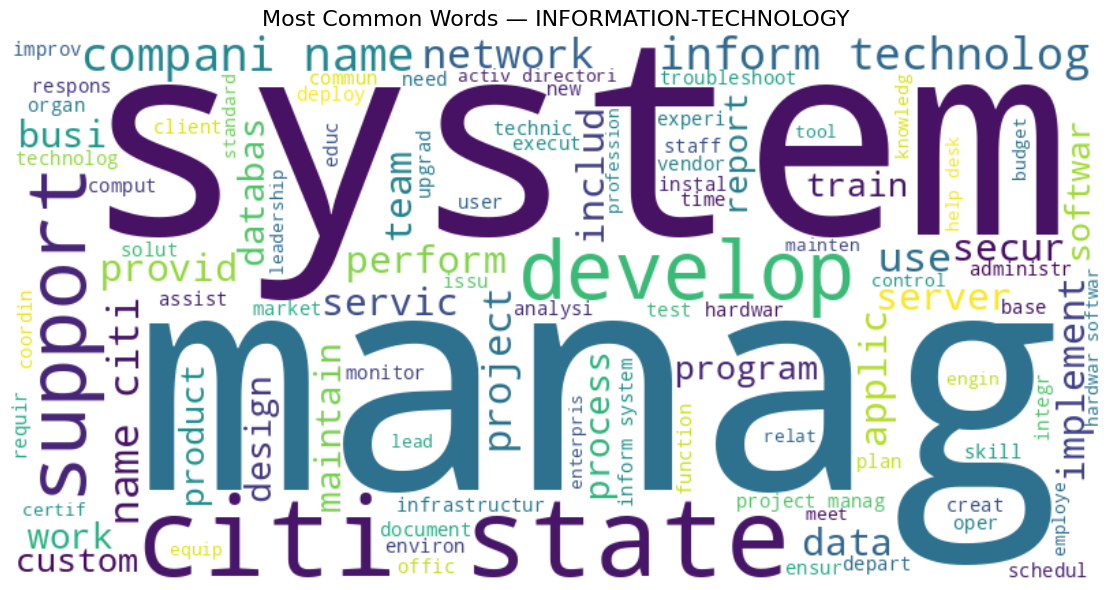

In [14]:
from wordcloud import WordCloud

category_to_viz = 'INFORMATION-TECHNOLOGY'  # change as you like

text = ' '.join(df[df['Category'] == category_to_viz]['Cleaned_Resume'])

wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      max_words=100,
                      colormap='viridis').generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title(f'Most Common Words — {category_to_viz}', fontsize=16)
plt.tight_layout()
plt.show()

# Average Score by Category

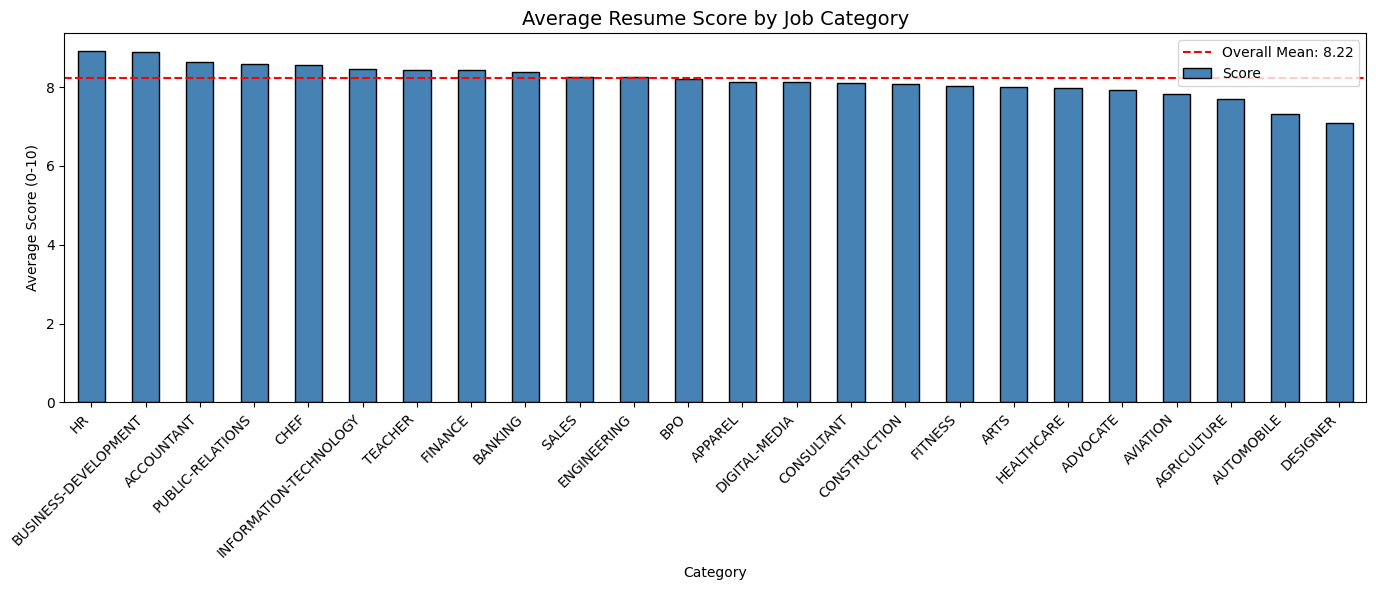

Category
HR                        8.918182
BUSINESS-DEVELOPMENT      8.900000
ACCOUNTANT                8.639831
PUBLIC-RELATIONS          8.576577
CHEF                      8.550847
INFORMATION-TECHNOLOGY    8.466667
TEACHER                   8.426471
FINANCE                   8.423729
BANKING                   8.382609
SALES                     8.262931
ENGINEERING               8.254237
BPO                       8.204545
APPAREL                   8.139175
DIGITAL-MEDIA             8.135417
CONSULTANT                8.095652
CONSTRUCTION              8.080357
FITNESS                   8.038462
ARTS                      7.995146
HEALTHCARE                7.973913
ADVOCATE                  7.936441
AVIATION                  7.829060
AGRICULTURE               7.690476
AUTOMOBILE                7.305556
DESIGNER                  7.098131
Name: Score, dtype: float64


In [15]:
plt.figure(figsize=(14, 6))
category_scores = df.groupby('Category')['Score'].mean().sort_values(ascending=False)
category_scores.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average Resume Score by Job Category', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Average Score (0-10)')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=df['Score'].mean(), color='red', linestyle='--', label=f'Overall Mean: {df["Score"].mean():.2f}')
plt.legend()
plt.tight_layout()
plt.show()

print(category_scores)

# Cluster vs Actual Category Heatmap

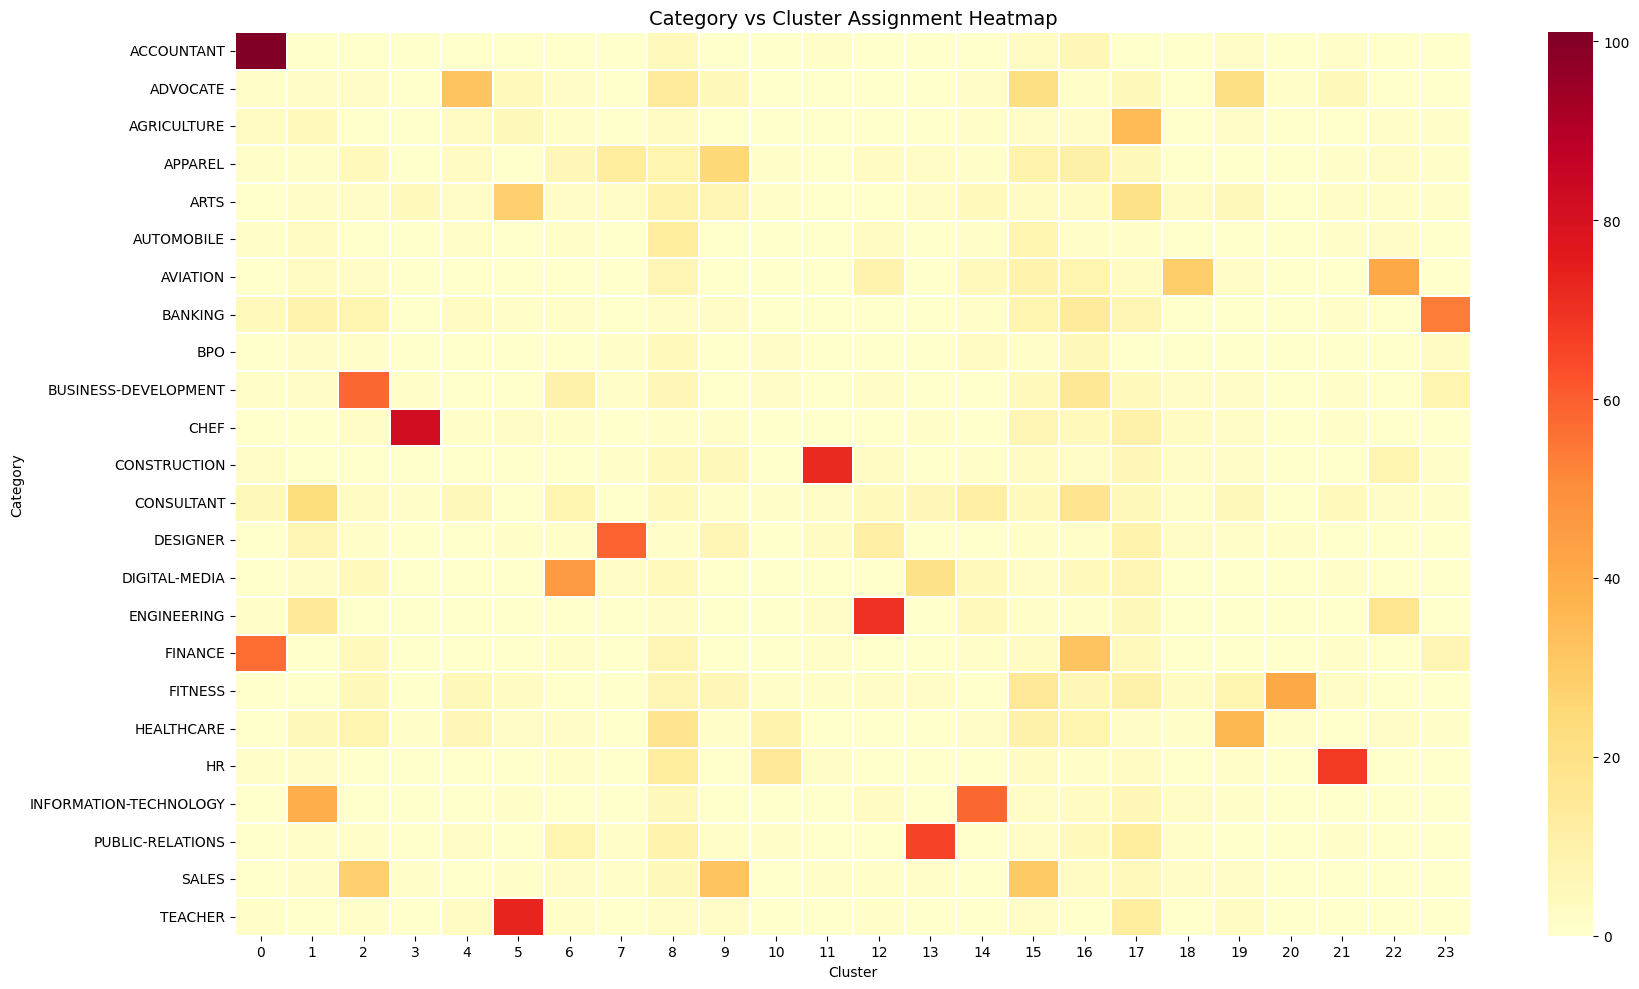

In [16]:
import seaborn as sns

ct = pd.crosstab(df['Category'], df['Cluster'])

plt.figure(figsize=(18, 10))
sns.heatmap(ct, cmap='YlOrRd', linewidths=0.3, annot=False)
plt.title('Category vs Cluster Assignment Heatmap', fontsize=14)
plt.xlabel('Cluster')
plt.ylabel('Category')
plt.tight_layout()
plt.show()